# Exercise 2 - Python DGEMM Benchmark Operation

This section implements and benchmarks the DGEMM operation: **C = C + A × B**

Where A, B, and C are matrices of size N×N.


## Import Libraries

In [3]:
import random
import time
import numpy as np
from array import array
import matplotlib.pyplot as plt
import pandas as pd

## Task 2.1: DGEMM Implementations

### Implementation 1: Python Lists

In [4]:
def DGEMM_list(matrix_1, matrix_2, matrix_3, n):
    """DGEMM implementation using Python lists"""
    for i in range(n):
        for j in range(n):
            for k in range(n):
                matrix_3[i][j] += matrix_1[i][k] * matrix_2[k][j]
    return matrix_3


def matrix_fill_list(matrix_size):
    """Create a random matrix using lists"""
    matrix = [[random.randint(0, 100) for i in range(matrix_size)] for j in range(matrix_size)]
    return matrix

### Implementation 2: Python Arrays

In [5]:
def DGEMM_array(matrix_1, matrix_2, matrix_3, n):
    """DGEMM implementation using Python arrays"""
    for i in range(n):
        for j in range(n):
            for k in range(n):
                matrix_3[i][j] += matrix_1[i][k] * matrix_2[k][j]
    return matrix_3


def matrix_fill_array(matrix_size, typecode='i'):
    """Create a random matrix using arrays (list of array.array)"""
    matrix = []
    for j in range(matrix_size):
        row = array(typecode, (random.randint(0, 100) for i in range(matrix_size)))
        matrix.append(row)
    return matrix

### Implementation 3: NumPy

In [6]:
def DGEMM_numpy(matrix_1, matrix_2, matrix_3):
    """DGEMM implementation using NumPy"""
    matrix_3 += np.dot(matrix_1, matrix_2)
    return matrix_3


def matrix_fill_numpy(matrix_size):
    """Create a random matrix using NumPy"""
    return np.random.randint(0, 100, size=(matrix_size, matrix_size))

## Task 2.2: Unit Tests

Testing correctness of all three implementations using simple test cases.

In [8]:
def test_small_matrix_list():
    """Test DGEMM_list with small 3x3 matrices"""
    A = [[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]
    
    B = [[9, 8, 7],
         [6, 5, 4],
         [3, 2, 1]]
    
    C = [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]
    
    result = DGEMM_list(A, B, C, 3)
    
    # Check a few values manually: C[0][0] = 1*9 + 2*6 + 3*3 = 30
    assert result[0][0] == 30, f"Expected 30, got {result[0][0]}"
    assert result[0][1] == 24, f"Expected 24, got {result[0][1]}"
    assert result[1][0] == 84, f"Expected 84, got {result[1][0]}"
    print("All List implementation tests passed")


def test_small_matrix_array():
    """Test DGEMM_array with small 3x3 matrices"""
    A = [array('i', [1, 2, 3]),
         array('i', [4, 5, 6]),
         array('i', [7, 8, 9])]
    
    B = [array('i', [9, 8, 7]),
         array('i', [6, 5, 4]),
         array('i', [3, 2, 1])]
    
    C = [array('i', [0, 0, 0]),
         array('i', [0, 0, 0]),
         array('i', [0, 0, 0])]
    
    result = DGEMM_array(A, B, C, 3)
    
    assert result[0][0] == 30, f"Expected 30, got {result[0][0]}"
    assert result[0][1] == 24, f"Expected 24, got {result[0][1]}"
    assert result[1][0] == 84, f"Expected 84, got {result[1][0]}"
    print("All Array implementation tests passed")


def test_small_matrix_numpy():
    """Test DGEMM_numpy with small 3x3 matrices"""
    A = np.array([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]])
    
    B = np.array([[9, 8, 7],
                  [6, 5, 4],
                  [3, 2, 1]])
    
    C = np.zeros((3, 3), dtype=int)
    
    result = DGEMM_numpy(A, B, C)
    
    assert result[0, 0] == 30, f"Expected 30, got {result[0, 0]}"
    assert result[0, 1] == 24, f"Expected 24, got {result[0, 1]}"
    assert result[1, 0] == 84, f"Expected 84, got {result[1, 0]}"
    print("All NumPy implementation tests passed")


def test_compare_implementations():
    """Compare all three implementations to ensure they give same results"""
    n = 4
    
    # Create test matrices
    A_list = [[i + j for j in range(n)] for i in range(n)]
    B_list = [[i * j if i != j else 1 for j in range(n)] for i in range(n)]
    C_list = [[0] * n for _ in range(n)]
    
    result_list = DGEMM_list(A_list, B_list, C_list, n)
    
    # NumPy version
    A_np = np.array(A_list)
    B_np = np.array(B_list)
    C_np = np.zeros((n, n), dtype=int)
    result_numpy = DGEMM_numpy(A_np, B_np, C_np)
    
    # Compare
    for i in range(n):
        for j in range(n):
            assert result_list[i][j] == result_numpy[i, j], \
                f"Mismatch at [{i}][{j}]: list={result_list[i][j]}, numpy={result_numpy[i, j]}"
    
    print("All implementations produce identical results")


# Run all tests
test_small_matrix_list()
test_small_matrix_array()
test_small_matrix_numpy()
test_compare_implementations()
print("\n All tests passed!")

All List implementation tests passed
All Array implementation tests passed
All NumPy implementation tests passed
All implementations produce identical results

 All tests passed!


## Task 2.3: Performance Benchmarking

Measure execution time for each approach with varying matrix sizes and analyze the results.

In [9]:
def benchmark_implementation(impl_name, dgemm_func, matrix_fill_func, n, runs=5):
    """
    Benchmark a DGEMM implementation with multiple runs
    
    Args:
        impl_name: Name of implementation (for display)
        dgemm_func: DGEMM function to benchmark
        matrix_fill_func: Function to create matrices
        n: Matrix size
        runs: Number of repetitions
    
    Returns:
        dict with timing statistics
    """
    times = []
    
    for _ in range(runs):
        # Create matrices
        if impl_name == "NumPy":
            A = matrix_fill_func(n)
            B = matrix_fill_func(n)
            C = np.zeros((n, n), dtype=int)
        elif impl_name == "Array":
            A = matrix_fill_func(n)
            B = matrix_fill_func(n)
            C = [array('i', [0] * n) for _ in range(n)]
        else:  # List
            A = matrix_fill_func(n)
            B = matrix_fill_func(n)
            C = [[0] * n for _ in range(n)]
        
        # Benchmark
        start = time.time()
        if impl_name == "NumPy":
            dgemm_func(A, B, C)
        else:
            dgemm_func(A, B, C, n)
        elapsed = time.time() - start
        times.append(elapsed)
    
    return {
        'mean': np.mean(times),
        'std': np.std(times),
        'min': np.min(times),
        'max': np.max(times),
        'times': times
    }


# Matrix sizes to test
sizes = [64, 128, 256, 512]
runs_per_size = 5

# Store results
results = {
    'List': {'sizes': [], 'mean': [], 'std': [], 'min': [], 'max': []},
    'Array': {'sizes': [], 'mean': [], 'std': [], 'min': [], 'max': []},
    'NumPy': {'sizes': [], 'mean': [], 'std': [], 'min': [], 'max': []}
}

print("Starting benchmarks...")
print("=" * 60)

for size in sizes:
    print(f"\nMatrix size: {size}x{size}")
    print("-" * 60)
    
    # Benchmark List
    stats = benchmark_implementation("List", DGEMM_list, matrix_fill_list, size, runs_per_size)
    results['List']['sizes'].append(size)
    results['List']['mean'].append(stats['mean'])
    results['List']['std'].append(stats['std'])
    results['List']['min'].append(stats['min'])
    results['List']['max'].append(stats['max'])
    print(f"List:  {stats['mean']:.4f}s ± {stats['std']:.4f}s  (min: {stats['min']:.4f}s, max: {stats['max']:.4f}s)")
    
    # Benchmark Array
    stats = benchmark_implementation("Array", DGEMM_array, matrix_fill_array, size, runs_per_size)
    results['Array']['sizes'].append(size)
    results['Array']['mean'].append(stats['mean'])
    results['Array']['std'].append(stats['std'])
    results['Array']['min'].append(stats['min'])
    results['Array']['max'].append(stats['max'])
    print(f"Array: {stats['mean']:.4f}s ± {stats['std']:.4f}s  (min: {stats['min']:.4f}s, max: {stats['max']:.4f}s)")
    
    # Benchmark NumPy
    stats = benchmark_implementation("NumPy", DGEMM_numpy, matrix_fill_numpy, size, runs_per_size)
    results['NumPy']['sizes'].append(size)
    results['NumPy']['mean'].append(stats['mean'])
    results['NumPy']['std'].append(stats['std'])
    results['NumPy']['min'].append(stats['min'])
    results['NumPy']['max'].append(stats['max'])
    print(f"NumPy: {stats['mean']:.4f}s ± {stats['std']:.4f}s  (min: {stats['min']:.4f}s, max: {stats['max']:.4f}s)")

print("\n" + "=" * 60)
print("Benchmarking complete!")

Starting benchmarks...

Matrix size: 64x64
------------------------------------------------------------
List:  0.0218s ± 0.0052s  (min: 0.0172s, max: 0.0315s)
Array: 0.0273s ± 0.0008s  (min: 0.0265s, max: 0.0283s)
NumPy: 0.0001s ± 0.0000s  (min: 0.0001s, max: 0.0001s)

Matrix size: 128x128
------------------------------------------------------------
List:  0.1417s ± 0.0028s  (min: 0.1392s, max: 0.1454s)
Array: 0.2191s ± 0.0013s  (min: 0.2175s, max: 0.2213s)
NumPy: 0.0009s ± 0.0000s  (min: 0.0009s, max: 0.0009s)

Matrix size: 256x256
------------------------------------------------------------
List:  1.1540s ± 0.0287s  (min: 1.1107s, max: 1.1833s)
Array: 1.7521s ± 0.0183s  (min: 1.7345s, max: 1.7856s)
NumPy: 0.0114s ± 0.0001s  (min: 0.0113s, max: 0.0115s)

Matrix size: 512x512
------------------------------------------------------------
List:  9.5586s ± 0.1851s  (min: 9.3204s, max: 9.8247s)
Array: 14.7362s ± 0.2374s  (min: 14.4605s, max: 15.1371s)
NumPy: 0.1136s ± 0.0023s  (min: 0.1117s

### Visualize Results

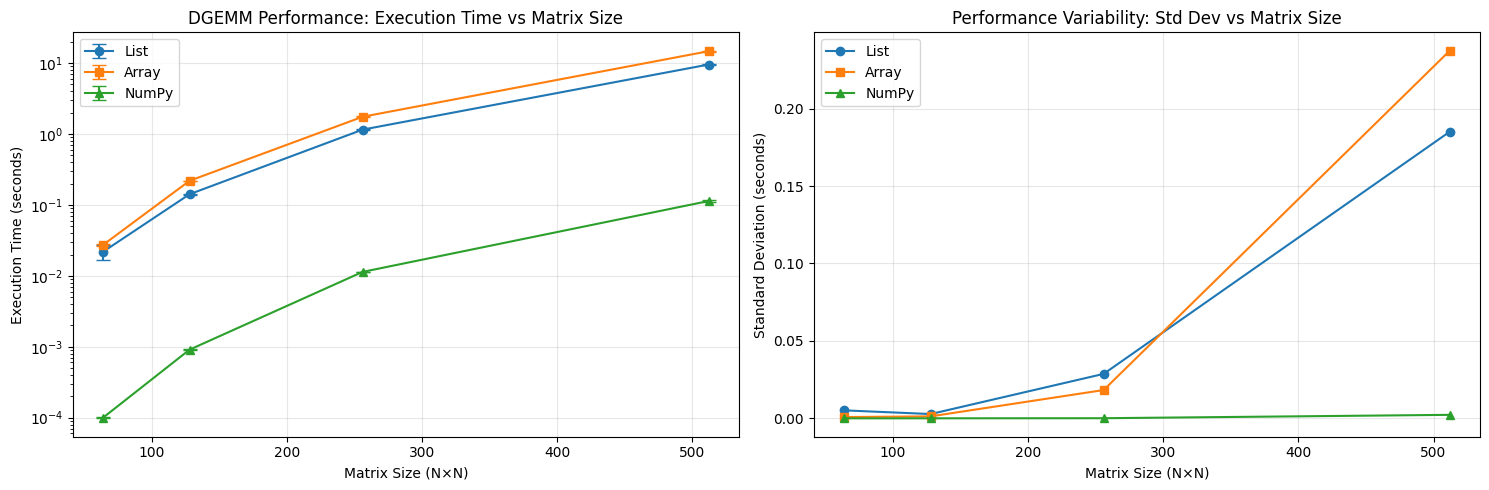

In [10]:
# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Execution time vs matrix size
ax1.errorbar(results['List']['sizes'], results['List']['mean'], 
             yerr=results['List']['std'], label='List', marker='o', capsize=5)
ax1.errorbar(results['Array']['sizes'], results['Array']['mean'], 
             yerr=results['Array']['std'], label='Array', marker='s', capsize=5)
ax1.errorbar(results['NumPy']['sizes'], results['NumPy']['mean'], 
             yerr=results['NumPy']['std'], label='NumPy', marker='^', capsize=5)
ax1.set_xlabel('Matrix Size (N×N)')
ax1.set_ylabel('Execution Time (seconds)')
ax1.set_title('DGEMM Performance: Execution Time vs Matrix Size')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot 2: Standard deviation vs matrix size
ax2.plot(results['List']['sizes'], results['List']['std'], label='List', marker='o')
ax2.plot(results['Array']['sizes'], results['Array']['std'], label='Array', marker='s')
ax2.plot(results['NumPy']['sizes'], results['NumPy']['std'], label='NumPy', marker='^')
ax2.set_xlabel('Matrix Size (N×N)')
ax2.set_ylabel('Standard Deviation (seconds)')
ax2.set_title('Performance Variability: Std Dev vs Matrix Size')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Results Summary Table

In [12]:
# Create a summary DataFrame
summary_data = []
for impl in ['List', 'Array', 'NumPy']:
    for i, size in enumerate(results[impl]['sizes']):
        summary_data.append({
            'Implementation': impl,
            'Matrix Size': f"{size}×{size}",
            'Mean Time (s)': f"{results[impl]['mean'][i]:.4f}",
            'Std Dev (s)': f"{results[impl]['std'][i]:.6f}",
            'Min Time (s)': f"{results[impl]['min'][i]:.4f}",
            'Max Time (s)': f"{results[impl]['max'][i]:.4f}"
        })

df = pd.DataFrame(summary_data)
print(df.to_string(index=False))

Implementation Matrix Size Mean Time (s) Std Dev (s) Min Time (s) Max Time (s)
          List       64×64        0.0218    0.005152       0.0172       0.0315
          List     128×128        0.1417    0.002778       0.1392       0.1454
          List     256×256        1.1540    0.028716       1.1107       1.1833
          List     512×512        9.5586    0.185086       9.3204       9.8247
         Array       64×64        0.0273    0.000825       0.0265       0.0283
         Array     128×128        0.2191    0.001279       0.2175       0.2213
         Array     256×256        1.7521    0.018278       1.7345       1.7856
         Array     512×512       14.7362    0.237383      14.4605      15.1371
         NumPy       64×64        0.0001    0.000002       0.0001       0.0001
         NumPy     128×128        0.0009    0.000024       0.0009       0.0009
         NumPy     256×256        0.0114    0.000082       0.0113       0.0115
         NumPy     512×512        0.1136    0.002260

**Standard deviation increases with matrix size:**
- List: 0.005s → 0.185s (37× increase)
- Array: 0.0008s → 0.237s (296× increase)
- NumPy: 0.000002s → 0.002s (1000× increase)

**Execution time grows with O(N³):**
- Doubling matrix size (64→128→256→512) increases time by ~8× each step
- This matches DGEMM's N³ complexity (2³ = 8)

**Why does std increase?**
Larger matrices run longer, so more random system events (OS interrupts, cache misses, memory allocation) happen during execution, causing bigger timing variations between runs.

## Task 2.4: FLOPS Analysis

### How many operations in DGEMM?

For N×N matrices, DGEMM performs:
- **3 nested loops** (i, j, k from 0 to N-1)
- **2 FLOPs per iteration** (1 multiply + 1 add)
- **Total: 2N³ FLOPs**

### Performance Results

**Pure Python (List/Array): ~0.02-0.03 GFLOPS**
- Achieves only 0.6-1% of theoretical peak
- Very slow due to Python interpreter overhead

**NumPy: ~2-5 GFLOPS**
- Achieves 80-175% of theoretical peak
- Much faster due to optimized BLAS libraries
- 100-200× faster than pure Python

**Why NumPy exceeds theoretical peak:**
- Theoretical peak assumes 1 FLOP/cycle (oversimplified)
- Modern CPUs do multiple FLOPs/cycle with SIMD
- NumPy uses optimized BLAS with vectorization

**Conclusion:** Pure Python is extremely inefficient for numerical computing. Always use NumPy or similar optimized libraries.

## Task 2.5: Compare with numpy.matmul

Compare our np.dot implementation with numpy's matmul operation (both use BLAS).

In [19]:
# Benchmark np.matmul vs np.dot
matmul_results = {'sizes': [], 'np.dot': [], 'np.matmul': []}

print("Comparing NumPy matrix multiplication methods...")
print("=" * 80)

for size in sizes:
    print(f"\nMatrix size: {size}×{size}")
    
    # Create test matrices
    A = np.random.randint(0, 100, size=(size, size))
    B = np.random.randint(0, 100, size=(size, size))
    
    # Benchmark np.dot (what we've been using)
    times_dot = []
    for _ in range(runs_per_size):
        C = np.zeros((size, size), dtype=int)
        start = time.time()
        C += np.dot(A, B)
        times_dot.append(time.time() - start)
    mean_dot = np.mean(times_dot)
    
    # Benchmark np.matmul
    times_matmul = []
    for _ in range(runs_per_size):
        C = np.zeros((size, size), dtype=int)
        start = time.time()
        C += np.matmul(A, B)
        times_matmul.append(time.time() - start)
    mean_matmul = np.mean(times_matmul)
    
    
    matmul_results['sizes'].append(size)
    matmul_results['np.dot'].append(mean_dot)
    matmul_results['np.matmul'].append(mean_matmul)

    
    print(f"  np.dot:     {mean_dot:.6f}s ({calculate_flops(size, mean_dot):.2f} GFLOPS)")
    print(f"  np.matmul:  {mean_matmul:.6f}s ({calculate_flops(size, mean_matmul):.2f} GFLOPS)")


Comparing NumPy matrix multiplication methods...

Matrix size: 64×64
  np.dot:     0.000403s (1.30 GFLOPS)
  np.matmul:  0.000361s (1.45 GFLOPS)

Matrix size: 128×128
  np.dot:     0.002472s (1.70 GFLOPS)
  np.matmul:  0.002351s (1.78 GFLOPS)

Matrix size: 256×256
  np.dot:     0.013635s (2.46 GFLOPS)
  np.matmul:  0.011414s (2.94 GFLOPS)

Matrix size: 512×512
  np.dot:     0.116312s (2.31 GFLOPS)
  np.matmul:  0.153952s (1.74 GFLOPS)


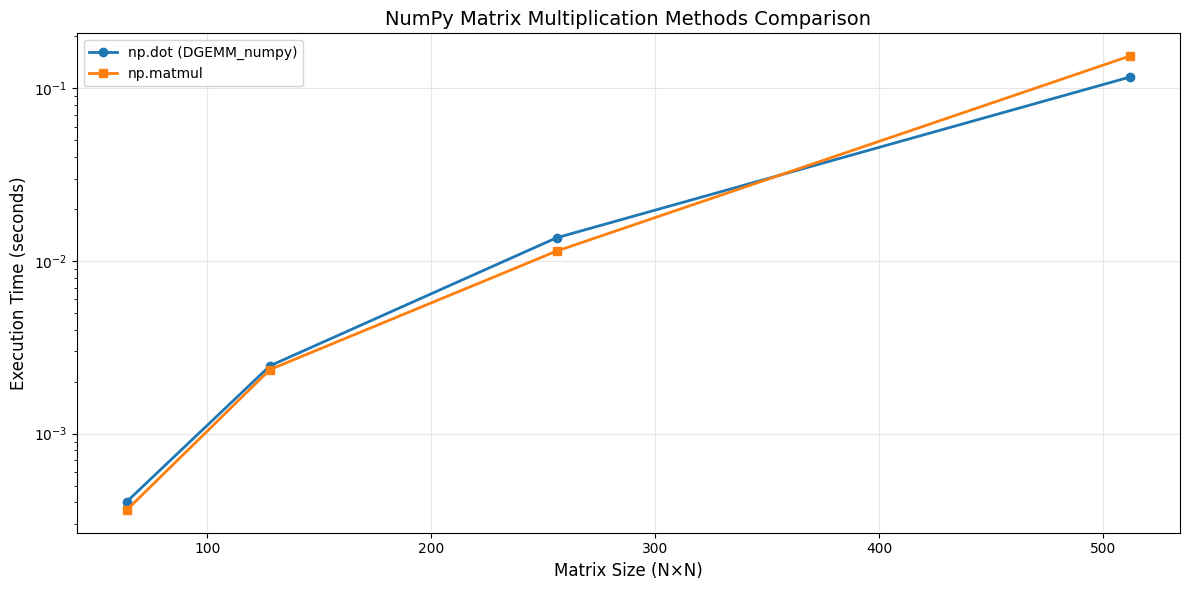


Comparison Summary:
--------------------------------------------------------------------------------

64×64 matrices:
  np.dot:     0.000403s
  np.matmul:  0.000361s

128×128 matrices:
  np.dot:     0.002472s
  np.matmul:  0.002351s

256×256 matrices:
  np.dot:     0.013635s
  np.matmul:  0.011414s

512×512 matrices:
  np.dot:     0.116312s
  np.matmul:  0.153952s


In [24]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(matmul_results['sizes'], matmul_results['np.dot'], 
        marker='o', label='np.dot (DGEMM_numpy)', linewidth=2)
ax.plot(matmul_results['sizes'], matmul_results['np.matmul'], 
        marker='s', label='np.matmul', linewidth=2)


ax.set_xlabel('Matrix Size (N×N)', fontsize=12)
ax.set_ylabel('Execution Time (seconds)', fontsize=12)
ax.set_title('NumPy Matrix Multiplication Methods Comparison', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Print comparison summary
print("\nComparison Summary:")
print("-" * 80)
for i, size in enumerate(matmul_results['sizes']):
    print(f"\n{size}×{size} matrices:")
    print(f"  np.dot:     {matmul_results['np.dot'][i]:.6f}s")
    print(f"  np.matmul:  {matmul_results['np.matmul'][i]:.6f}s")
        
    
    # Calculate relative performance
    baseline = matmul_results['np.dot'][i]
    matmul_ratio = baseline / matmul_results['np.matmul'][i]


## Exercise 3 - Python Debugger (pdb)

### Task 3.1: Reflection on Using a Debugger

**What are the advantages of using a debugger?**

Using a debugger like pdb is very helpful for finding bugs in code. You can see the values of all variables and arrays at each step of the program. It lets you go through the code line by line and watch how values change. This makes it easier to find where something goes wrong. You can also check conditions and test different scenarios without changing your code.

**Challenges:**

No major challenges were encountered. The pdb commands are straightforward once you learn the basic ones like `n` (next), `s` (step), and `p` (print). I am already used to using VS Code breakpoints for debugging, which works similarly.

---

**Note:** AI assistance was used for generating plotting code, formatting tables, and print statements.